In [ ]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Data manipulation and preprocessing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Model selection and evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

# Machine Learning models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Deep Learning
from keras.models import Sequential
from keras.layers import Dense, Embedding, LSTM, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences

# System
import os
import datetime

# NLP resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
import os
import pandas as pd

# Assuming kagglehub has already provided the dataset path
import kagglehub
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")

# Define file paths
fake_path = os.path.join(path, 'Fake.csv')
real_path = os.path.join(path, 'True.csv')

# Load datasets
df_fake = pd.read_csv(fake_path)
df_real = pd.read_csv(real_path)

# Add label column: 0 = Fake, 1 = Real
df_fake['label'] = 0
df_real['label'] = 1

# Combine datasets
df = pd.concat([df_fake, df_real], ignore_index=True)

# Shuffle the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Display basic info
print("Dataset shape:", df.shape)
print(df['label'].value_counts())
df.head()

Dataset shape: (44898, 5)
label
0    23481
1    21417
Name: count, dtype: int64


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [ ]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Initialize stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Text cleaning function
def clean_text(text):
    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove punctuation and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords and lemmatize
    tokens = text.split()
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    return ' '.join(cleaned_tokens)

# Apply cleaning
df['clean_text'] = df['text'].apply(clean_text)

# Check result
df[['clean_text', 'label']].head()

,clean_text,label
0,st century wire say ben stein reputable profes...,0
1,washington reuters u president donald trump re...,1
2,reuters puerto rico governor ricardo rossello ...,1
3,monday donald trump embarrassed country accide...,0
4,glasgow scotland reuters u presidential candid...,1


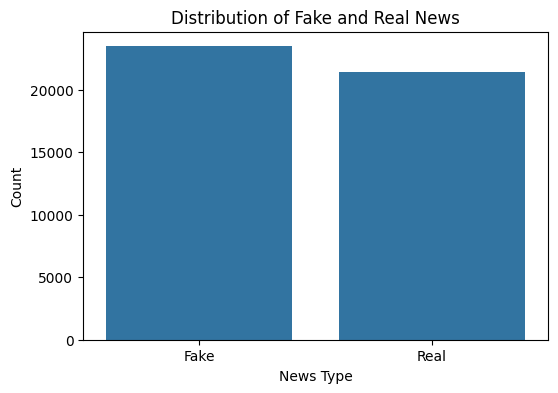

In [ ]:
# Plot label distribution
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.xticks([0, 1], ['Fake', 'Real'])
plt.title('Distribution of Fake and Real News')
plt.xlabel('News Type')
plt.ylabel('Count')
plt.show()

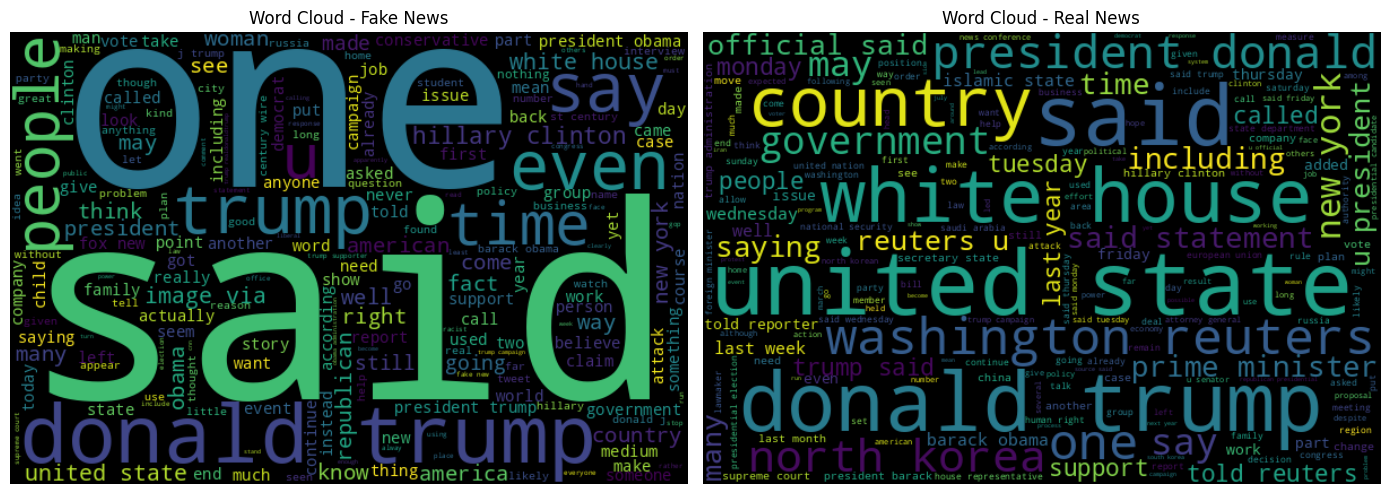

In [ ]:
from wordcloud import WordCloud

# Fake news word cloud
fake_words = ' '.join(df[df['label'] == 0]['clean_text'])
real_words = ' '.join(df[df['label'] == 1]['clean_text'])

plt.figure(figsize=(14,6))

# Fake
plt.subplot(1, 2, 1)
wc = WordCloud(width=600, height=400, background_color='black').generate(fake_words)
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Fake News")

# Real
plt.subplot(1, 2, 2)
wc = WordCloud(width=600, height=400, background_color='black').generate(real_words)
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Real News")

plt.tight_layout()
plt.show()

In [ ]:
from collections import Counter

def get_top_n_words(corpus, n=20):
    words = ' '.join(corpus).split()
    counter = Counter(words)
    return counter.most_common(n)

# Top 20 words in Fake and Real news
fake_top_words = get_top_n_words(df[df['label']==0]['clean_text'])
real_top_words = get_top_n_words(df[df['label']==1]['clean_text'])

# Plot
def plot_top_words(word_freq, title):
    words, counts = zip(*word_freq)
    plt.figure(figsize=(10,4))
    sns.barplot(x=list(words), y=list(counts))
    plt.xticks(rotation=45)
    plt.title(title)
    plt.show()

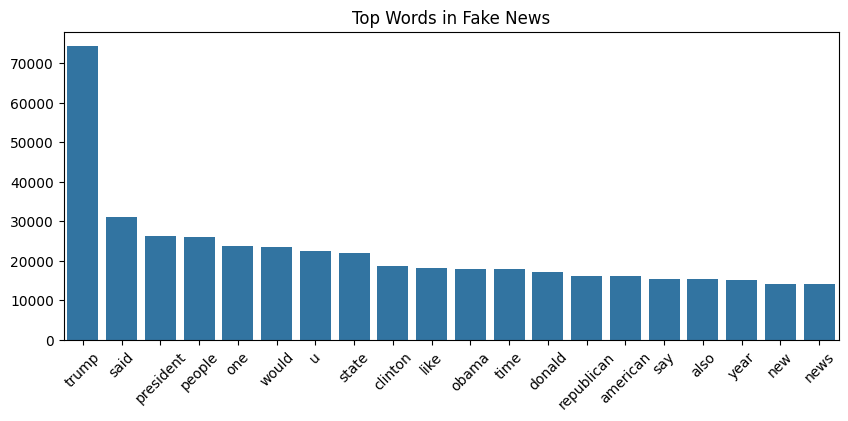

In [ ]:
plot_top_words(fake_top_words, "Top Words in Fake News")

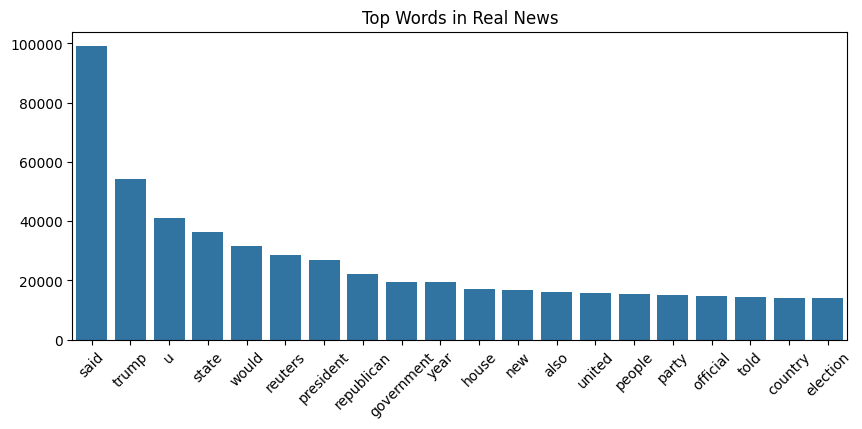

In [ ]:
plot_top_words(real_top_words, "Top Words in Real News")

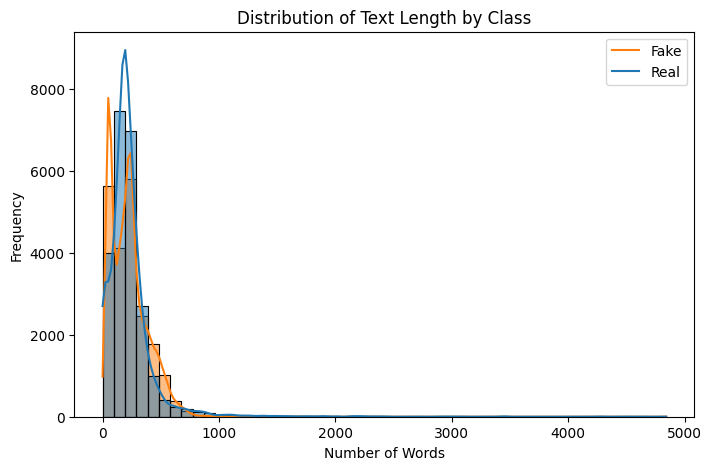

In [ ]:
# Add length columns
df['text_length'] = df['clean_text'].apply(lambda x: len(x.split()))

# Plot distribution
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='text_length', hue='label', bins=50, kde=True)
plt.title("Distribution of Text Length by Class")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.legend(['Fake', 'Real'])
plt.show()

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, ngram_range=(2, 2), n=20):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    return sorted(words_freq, key=lambda x: x[1], reverse=True)[:n]

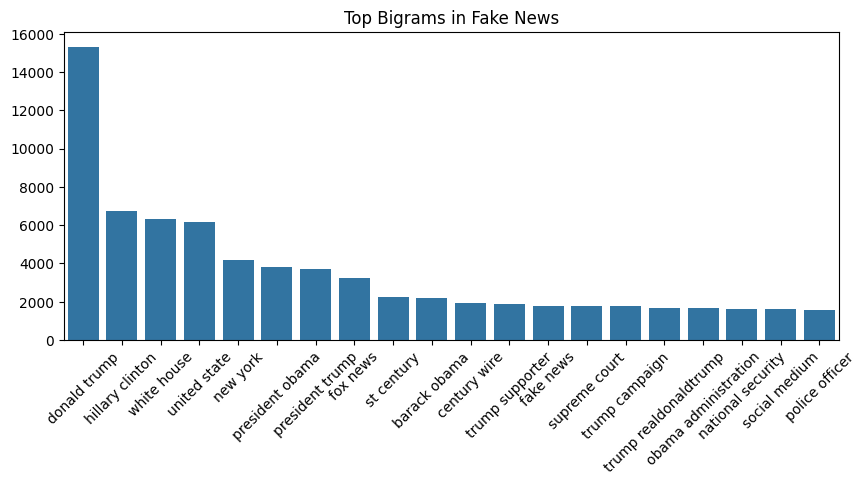

In [ ]:
# Top 20 bigrams for fake news
fake_bigrams = get_top_ngrams(df[df['label']==0]['clean_text'], ngram_range=(2,2))
plot_top_words(fake_bigrams, "Top Bigrams in Fake News")

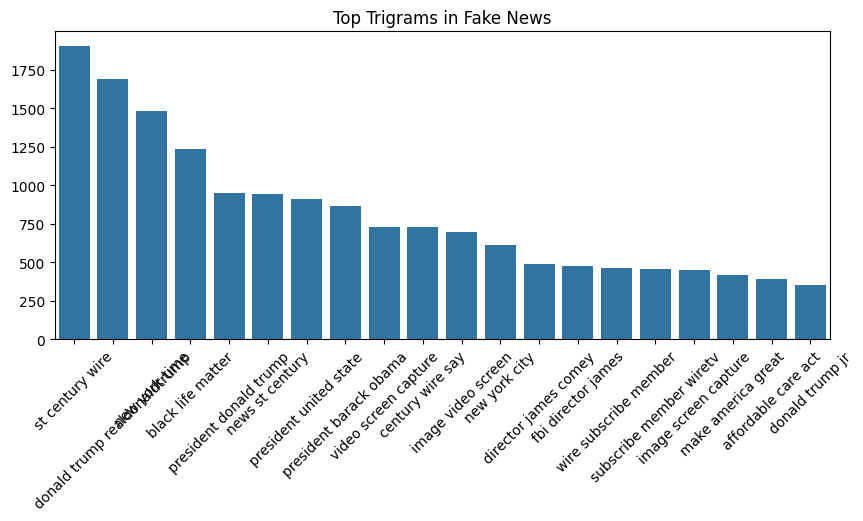

In [ ]:
# Function already defined earlier:
def get_top_ngrams(corpus, ngram_range=(3, 3), n=20):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    return sorted(words_freq, key=lambda x: x[1], reverse=True)[:n]

# Reuse the plot_top_words function
# Now extract and plot trigrams
fake_trigrams = get_top_ngrams(df[df['label'] == 0]['clean_text'], ngram_range=(3, 3))
plot_top_words(fake_trigrams, "Top Trigrams in Fake News")

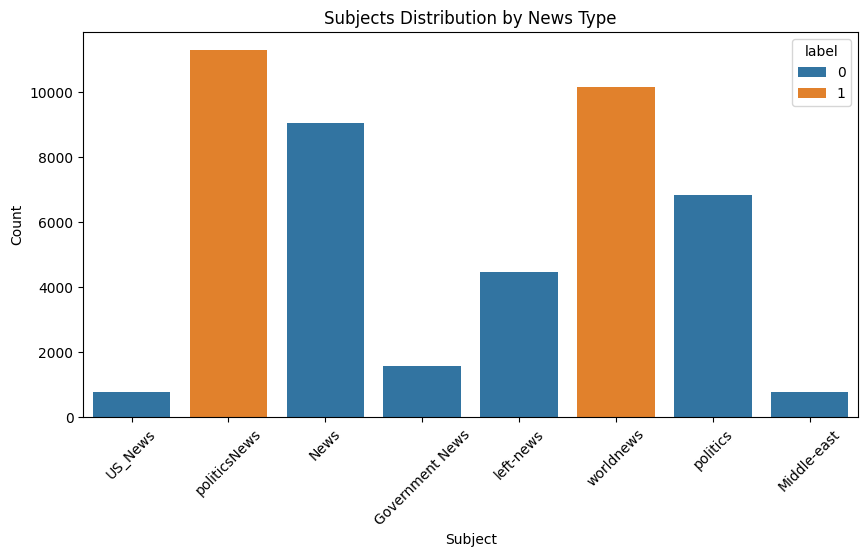

In [ ]:
if 'subject' in df.columns:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df, x='subject', hue='label')
    plt.xticks(rotation=45)
    plt.title("Subjects Distribution by News Type")
    plt.xlabel("Subject")
    plt.ylabel("Count")
    plt.show()

In [ ]:
# Check nulls
print("Null values:\n", df.isnull().sum())

# Check duplicates
print("Duplicate entries:", df.duplicated(subset='clean_text').sum())

Null values:
 title         0
text          0
subject       0
date          0
label         0
clean_text    0
dtype: int64
Duplicate entries: 6440


In [ ]:
# Drop duplicates based on 'clean_text'
df = df.drop_duplicates(subset='clean_text', keep='first').reset_index(drop=True)

# Confirm removal
print("New dataset shape:", df.shape)
print("Remaining duplicates:", df.duplicated(subset='clean_text').sum())

New dataset shape: (38458, 6)
Remaining duplicates: 0


In [ ]:
# Use clean_text as input and label as target
X = df['clean_text']
y = df['label']

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2), stop_words='english')
X_tfidf = tfidf.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, stratify=y, random_state=42
)

print("TF-IDF shape:", X_tfidf.shape)
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

TF-IDF shape: (38458, 10000)
Training set size: (30766, 10000)
Test set size: (7692, 10000)


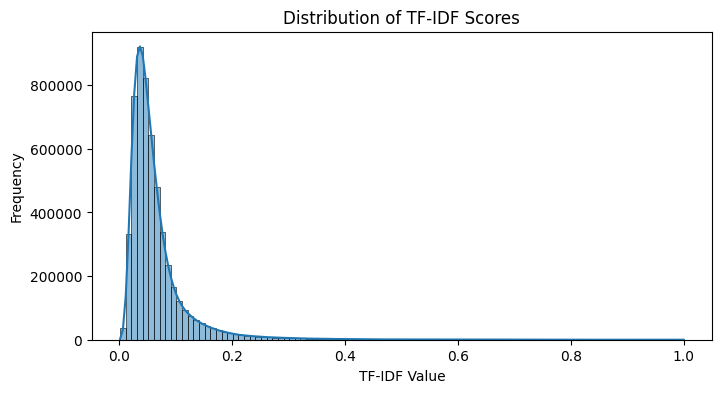

In [ ]:
# Plot distribution of TF-IDF scores
plt.figure(figsize=(8, 4))
sns.histplot(X_tfidf.data, bins=100, kde=True)
plt.title("Distribution of TF-IDF Scores")
plt.xlabel("TF-IDF Value")
plt.ylabel("Frequency")
plt.show()

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Train the model
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test)

# Evaluation
print(" SVM Classification Report:")
print(classification_report(y_test, y_pred_svm, target_names=["Fake", "Real"]))

print("Confusion Matrix (SVM):")
print(confusion_matrix(y_test, y_pred_svm))

print("ROC-AUC Score (SVM):", roc_auc_score(y_test, y_pred_svm))

 SVM Classification Report:
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      3479
        Real       0.99      0.99      0.99      4213

    accuracy                           0.99      7692
   macro avg       0.99      0.99      0.99      7692
weighted avg       0.99      0.99      0.99      7692

Confusion Matrix (SVM):
[[3452   27]
 [  23 4190]]
ROC-AUC Score (SVM): 0.9933899282576201


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluation
print("\n Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=["Fake", "Real"]))

print("Confusion Matrix (Random Forest):")
print(confusion_matrix(y_test, y_pred_rf))

print("ROC-AUC Score (Random Forest):", roc_auc_score(y_test, y_pred_rf))


 Random Forest Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      0.99      1.00      3479
        Real       0.99      1.00      1.00      4213

    accuracy                           1.00      7692
   macro avg       1.00      1.00      1.00      7692
weighted avg       1.00      1.00      1.00      7692

Confusion Matrix (Random Forest):
[[3456   23]
 [   6 4207]]
ROC-AUC Score (Random Forest): 0.9959823707768294


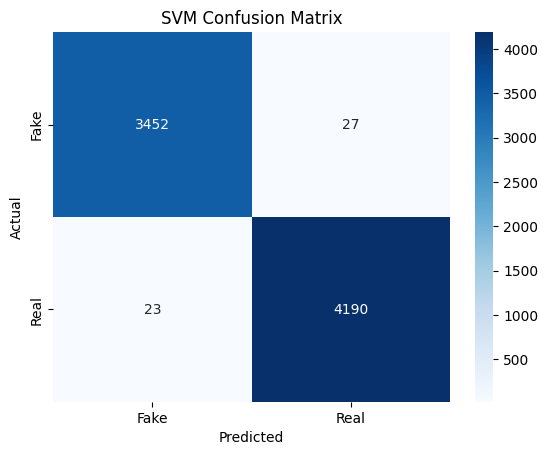

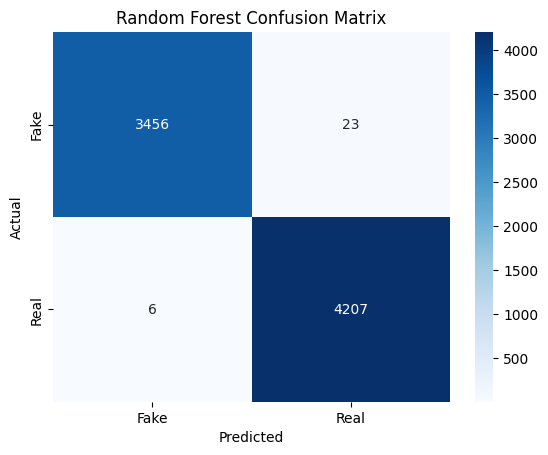

In [ ]:
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

plot_conf_matrix(y_test, y_pred_svm, "SVM Confusion Matrix")
plot_conf_matrix(y_test, y_pred_rf, "Random Forest Confusion Matrix")

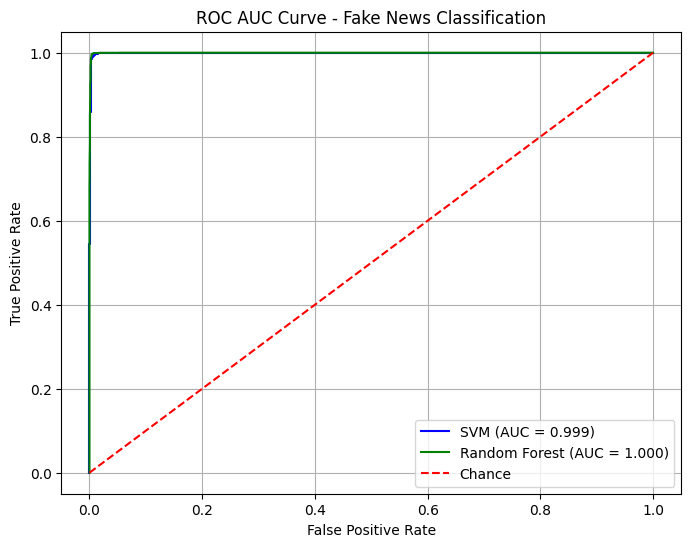

In [ ]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_curve, auc

# Calibrate SVM for probabilities
svm_calibrated = CalibratedClassifierCV(estimator=LinearSVC(), cv=5)
svm_calibrated.fit(X_train, y_train)

# Get probability estimates for SVM
y_probs_svm = svm_calibrated.predict_proba(X_test)[:, 1]

# Random Forest probability predictions
y_probs_rf = rf_model.predict_proba(X_test)[:, 1]

# Compute ROC curves and AUC
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_probs_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_probs_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot ROC Curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {roc_auc_svm:.3f})", color='blue')
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.3f})", color='green')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label="Chance")

plt.title("ROC AUC Curve - Fake News Classification")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from scipy.stats import uniform

# Define parameter grid for LinearSVC
param_dist_svm = {
    'C': uniform(loc=0.01, scale=10)
}

# Instantiate LinearSVC
svm = LinearSVC(dual=False, random_state=42, max_iter=5000)

# RandomizedSearchCV
svm_random = RandomizedSearchCV(
    estimator=svm,
    param_distributions=param_dist_svm,
    n_iter=20,
    scoring='f1',
    n_jobs=-1,
    cv=3,
    verbose=1,
    random_state=42
)

# Fit to vectorized data
svm_random.fit(X_train, y_train)

# Best model
best_svm = svm_random.best_estimator_

# Predict
y_pred_svm = best_svm.predict(X_test)

# Evaluation
print("\nBest Parameters (SVM):", svm_random.best_params_)
print("\nClassification Report (SVM):")
print(classification_report(y_test, y_pred_svm, target_names=["Fake", "Real"]))
print("Confusion Matrix (SVM):")
print(confusion_matrix(y_test, y_pred_svm))

# ROC-AUC using decision function
y_scores_svm = best_svm.decision_function(X_test)
print("ROC-AUC Score (SVM):", roc_auc_score(y_test, y_scores_svm))

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Parameters (SVM): {'C': np.float64(2.1333911067827613)}

Classification Report (SVM):
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      3479
        Real       0.99      0.99      0.99      4213

    accuracy                           0.99      7692
   macro avg       0.99      0.99      0.99      7692
weighted avg       0.99      0.99      0.99      7692

Confusion Matrix (SVM):
[[3450   29]
 [  23 4190]]
ROC-AUC Score (SVM): 0.9993227139446492


In [ ]:
import joblib

# Save model
joblib.dump(best_svm, "svm_model.pkl")

# Save TF-IDF vectorizer
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("SVM model and vectorizer saved successfully.")

SVM model and vectorizer saved successfully.


In [ ]:
# Load saved model and vectorizer
best_svm = joblib.load("best_svm_model.pkl")
tfidf = joblib.load("tfidf_vectorizer.pkl")

LIME explanation for SVM (sample index: 10):


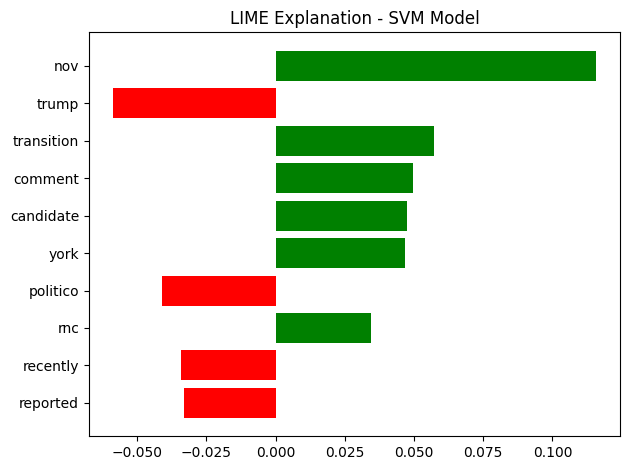

In [ ]:
from lime.lime_text import LimeTextExplainer
import numpy as np
from sklearn.utils.extmath import softmax
import matplotlib.pyplot as plt

# Define the class names
class_names = ['Fake', 'Real']

# Define a prediction function using decision_function + softmax
def svm_predict_fn(texts):
    decision_scores = best_svm.decision_function(tfidf.transform(texts))
    if len(decision_scores.shape) == 1:
        decision_scores = np.vstack([-decision_scores, decision_scores]).T
    return softmax(decision_scores)

# Create a LIME explainer
explainer = LimeTextExplainer(class_names=class_names)

# Pick a sample text from the test set
idx = 10
sample_text = df['clean_text'].iloc[idx]

# Generate explanation
exp = explainer.explain_instance(sample_text, svm_predict_fn, num_features=10)

# Show explanation
print("LIME explanation for SVM (sample index: {}):".format(idx))
fig = exp.as_pyplot_figure()
plt.title("LIME Explanation - SVM Model")
plt.tight_layout()
plt.show()

Explanation for FAKE news sample:


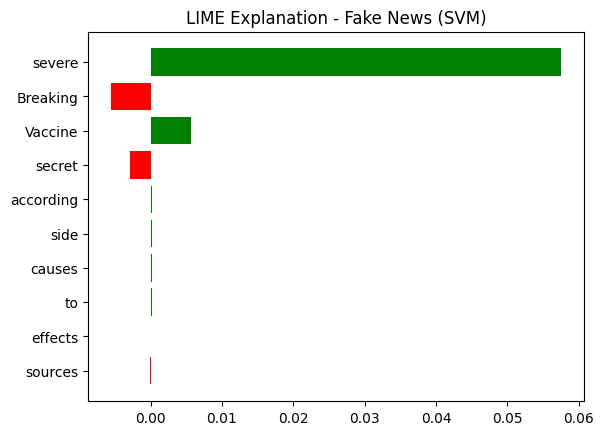

Explanation for REAL news sample:


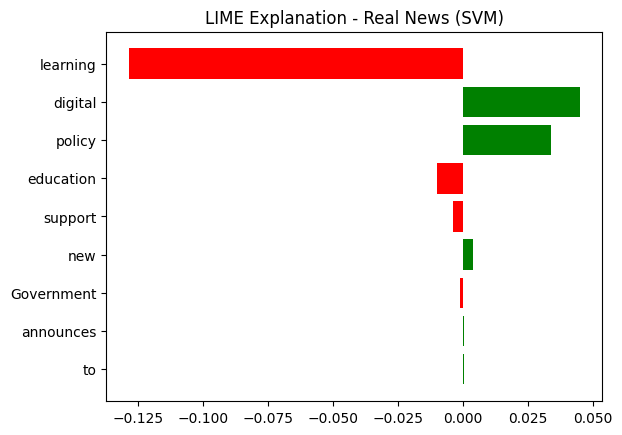

In [ ]:
from lime.lime_text import LimeTextExplainer
import matplotlib.pyplot as plt
import joblib

# Load saved model and vectorizer
best_svm = joblib.load("svm_model.pkl")
tfidf = joblib.load("tfidf_vectorizer.pkl")

# Define prediction function for LIME
class_names = ['Fake', 'Real']
def predict_fn(texts):
    return best_svm.decision_function(tfidf.transform(texts)).reshape(-1, 1) if len(texts) == 1 else best_svm.decision_function(tfidf.transform(texts))

# For binary classification, we wrap in proba-like structure for LIME
def predict_lime(texts):
    decision = predict_fn(texts)
    from sklearn.utils.extmath import softmax
    return softmax(np.c_[ -decision, decision ])  # Convert to pseudo-probabilities

# Create LIME explainer
explainer = LimeTextExplainer(class_names=class_names)

# Sample text examples (or use from test data)
sample_fake = "Breaking: Vaccine causes severe side effects according to secret sources."
sample_real = "Government announces new education policy to support digital learning."

# Explain FAKE news
exp_fake = explainer.explain_instance(sample_fake, predict_lime, num_features=10)
print("Explanation for FAKE news sample:")
fig_fake = exp_fake.as_pyplot_figure()
plt.title("LIME Explanation - Fake News (SVM)")
plt.show()

# Explain REAL news
exp_real = explainer.explain_instance(sample_real, predict_lime, num_features=10)
print("Explanation for REAL news sample:")
fig_real = exp_real.as_pyplot_figure()
plt.title("LIME Explanation - Real News (SVM)")
plt.show()

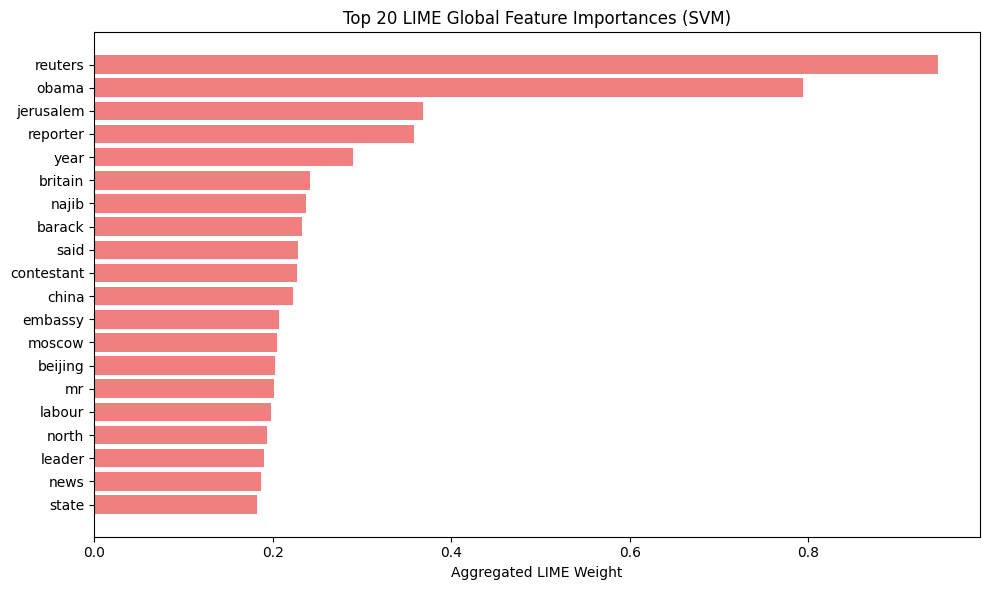

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from lime.lime_text import LimeTextExplainer

# Sample 50 test texts for interpretation
num_samples = 50
test_texts = df['clean_text'].iloc[X_test.indices[:num_samples]] if hasattr(X_test, 'indices') else df['clean_text'].iloc[:num_samples]

# Create explainer
explainer = LimeTextExplainer(class_names=['Fake', 'Real'])

# Prediction function for LIME (SVM)
def predict_lime(texts):
    decision = best_svm.decision_function(tfidf.transform(texts))
    from sklearn.utils.extmath import softmax
    return softmax(np.c_[-decision, decision])  # for binary classification

# Aggregate feature importances
feature_weights = defaultdict(float)

for text in test_texts:
    explanation = explainer.explain_instance(text, predict_lime, num_features=10)
    for feature, weight in explanation.as_list():
        feature_weights[feature] += abs(weight)

# Sort top features
sorted_features = sorted(feature_weights.items(), key=lambda x: x[1], reverse=True)[:20]
features, weights = zip(*sorted_features)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(range(len(features)), weights, color='lightcoral')
plt.yticks(range(len(features)), features)
plt.xlabel("Aggregated LIME Weight")
plt.title("Top 20 LIME Global Feature Importances (SVM)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from scipy.stats import randint
import numpy as np

# Define parameter grid
param_dist = {
    'n_estimators': randint(50, 150),
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Instantiate RandomForestClassifier
rf = RandomForestClassifier(random_state=42)

# Randomized Search
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,             # Number of combinations to try
    cv=3,                  # 3-fold cross-validation
    verbose=1,
    n_jobs=-1,             # Use all processors
    scoring='f1',          # Focus on F1 score
    random_state=42
)

# Fit
rf_random.fit(X_train, y_train)

# Best model
best_rf = rf_random.best_estimator_

# Predictions
y_pred = best_rf.predict(X_test)

# Evaluation
print("\n Best Parameters:", rf_random.best_params_)
print("\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Fake", "Real"]))

print(" Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("ROC-AUC Score:", roc_auc_score(y_test, y_pred))

Fitting 3 folds for each of 20 candidates, totalling 60 fits

 Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 56}

 Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      0.99      0.99      3479
        Real       0.99      1.00      0.99      4213

    accuracy                           0.99      7692
   macro avg       0.99      0.99      0.99      7692
weighted avg       0.99      0.99      0.99      7692

 Confusion Matrix:
[[3447   32]
 [  12 4201]]
ROC-AUC Score: 0.9939768139882666


In [ ]:
"""
import joblib

# Load the Random Forest model
best_rf = joblib.load("random_forest_model.pkl")

# Load the TF-IDF vectorizer
tfidf = joblib.load("tfidf_vectorizer.pkl")

print("Model and vectorizer loaded successfully.")
"""

Model and vectorizer loaded successfully.


In [ ]:
# pip install lime

In [ ]:
from lime.lime_text import LimeTextExplainer
import numpy as np

# Define a prediction function for LIME
class_names = ['Fake', 'Real']
predict_fn = lambda x: best_rf.predict_proba(tfidf.transform(x))

# Create explainer
explainer = LimeTextExplainer(class_names=class_names)

# Pick a sample input
idx = 10
sample_text = df['clean_text'].iloc[idx]

# Explain prediction
exp = explainer.explain_instance(sample_text, predict_fn, num_features=10)
exp.show_in_notebook(text=sample_text)

Explanation for FAKE news sample:


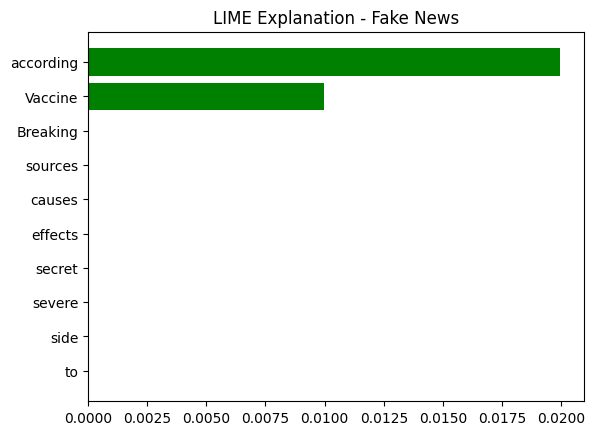

Explanation for REAL news sample:


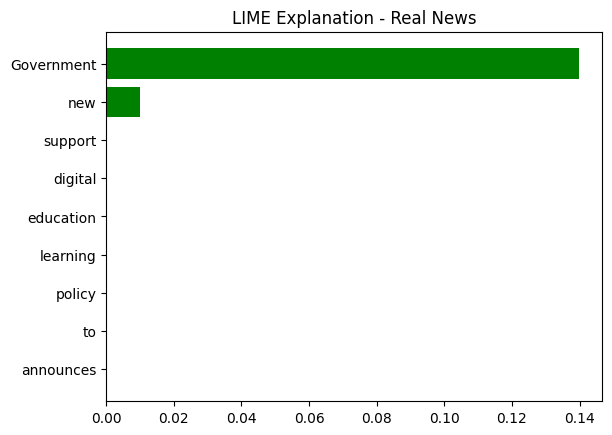

In [ ]:
import lime
import lime.lime_text
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

# Define LIME explainer
explainer = lime.lime_text.LimeTextExplainer(class_names=["Fake", "Real"])

# Define the prediction function
def predict_fn(texts):
    X_vec = tfidf.transform(texts)
    return best_rf.predict_proba(X_vec)

# Sample texts for each class
sample_fake = "Breaking: Vaccine causes severe side effects according to secret sources."
sample_real = "Government announces new education policy to support digital learning."

# Explain FAKE prediction
exp_fake = explainer.explain_instance(sample_fake, predict_fn, num_features=10)
print("Explanation for FAKE news sample:")
fig_fake = exp_fake.as_pyplot_figure()
plt.title("LIME Explanation - Fake News")
plt.show()

# Explain REAL prediction
exp_real = explainer.explain_instance(sample_real, predict_fn, num_features=10)
print("Explanation for REAL news sample:")
fig_real = exp_real.as_pyplot_figure()
plt.title("LIME Explanation - Real News")
plt.show()


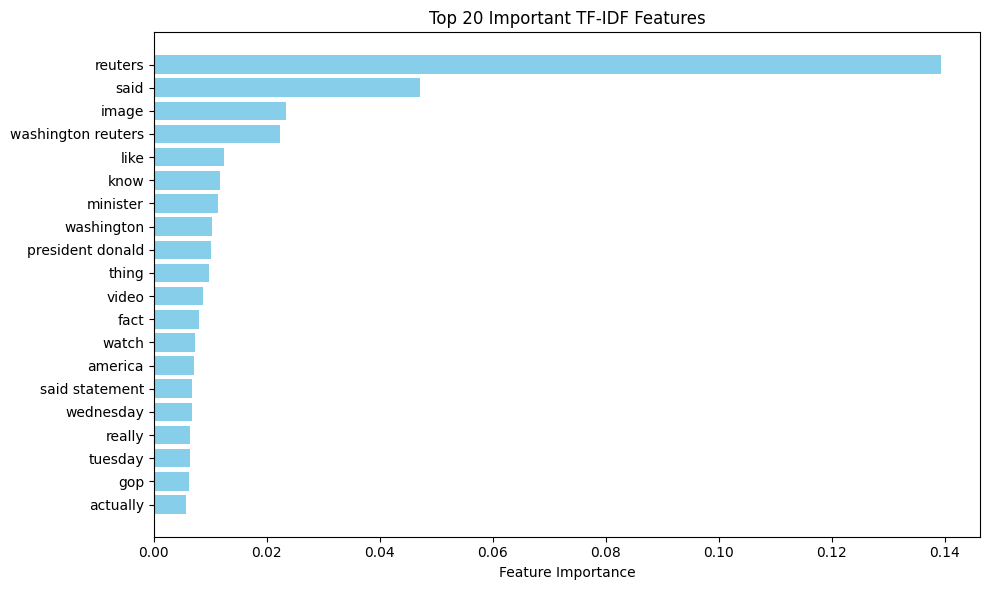

In [ ]:
# Get feature importances and names
importances = best_rf.feature_importances_
feature_names = tfidf.get_feature_names_out()

# Sort top N
indices = np.argsort(importances)[-20:]
plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], color='skyblue')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Feature Importance")
plt.title("Top 20 Important TF-IDF Features")
plt.tight_layout()
plt.show()

In [ ]:
# Assuming kagglehub has already provided the dataset path
import kagglehub
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")

# Define file paths
fake_path = os.path.join(path, 'Fake.csv')
real_path = os.path.join(path, 'True.csv')

# Load datasets
fake = pd.read_csv(fake_path)
real = pd.read_csv(real_path)

fake['label']=0
real['label']=1

df=pd.concat([fake,real] , ignore_index=True)
df=df.sample(frac=1).reset_index(drop=True)

In [ ]:
stop_words=set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = ' '.join(word for word in text.split() if word not in stop_words)
    return text

df['text']=df['text'].apply(clean_text)

In [ ]:
X=df['text'].values
y=df['label'].values

#Tokenize

tokenizer=Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X)
sequences=tokenizer.texts_to_sequences(X)

# Pad Sequences

max_len= 500
X_padded=pad_sequences(sequences , maxlen=max_len)

#Train_test_split

X_train,X_test,y_train,y_test=train_test_split(X_padded,y,test_size=0.2 ,random_state=42)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
from tensorflow.keras.regularizers import l2

model = Sequential()
model.add(Embedding(input_dim=5000, output_dim=128, input_length=max_len))
model.add(Bidirectional(LSTM(64, return_sequences=True, kernel_regularizer=l2(0.01))))
model.add(Dropout(0.5))
model.add(LSTM(32, kernel_regularizer=l2(0.01)))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam' , metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_schedule = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1,
    min_lr=1e-6
)

In [ ]:
history1 = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=128,
    callbacks=[lr_schedule],
    verbose=1
)

Epoch 1/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 16s 73ms/step - accuracy: 0.9614 - loss: 0.8636 - val_accuracy: 0.9653 - val_loss: 0.1854 - learning_rate: 0.0010
Epoch 2/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 17s 75ms/step - accuracy: 0.9804 - loss: 0.1313 - val_accuracy: 0.9740 - val_loss: 0.1168 - learning_rate: 0.0010
Epoch 3/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 16s 71ms/step - accuracy: 0.9906 - loss: 0.0702 - val_accuracy: 0.9807 - val_loss: 0.1216 - learning_rate: 0.0010
Epoch 4/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 25s 92ms/step - accuracy: 0.9906 - loss: 0.0697 - val_accuracy: 0.9875 - val_loss: 0.0635 - learning_rate: 0.0010
Epoch 5/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 40s 90ms/step - accuracy: 0.9903 - loss: 0.0526 - val_accuracy: 0.9500 - val_loss: 0.2595 - learning_rate: 0.0010


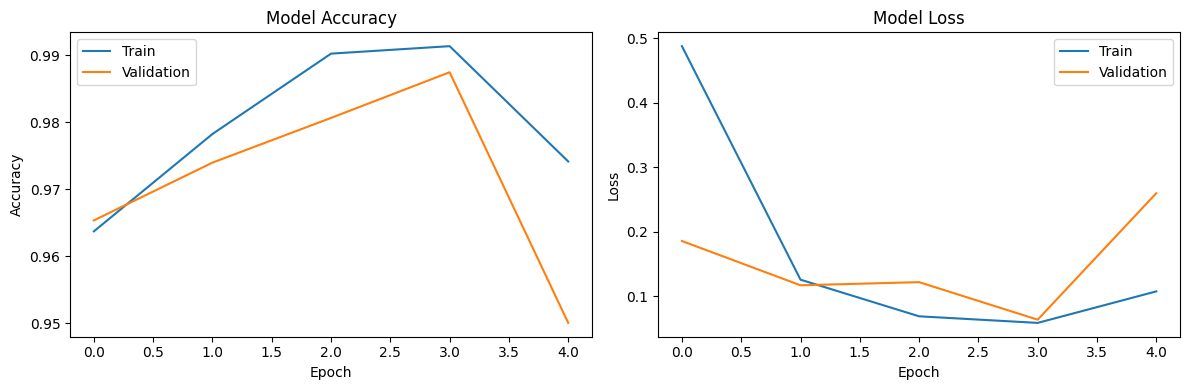

In [ ]:
def plot_history(history):
    plt.figure(figsize=(12, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history1)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import numpy as np

# Predict probabilities
y_probs = model.predict(X_test)
y_pred = (y_probs > 0.5).astype(int)

# Classification report
print(classification_report(y_test, y_pred))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_probs)
print("ROC-AUC Score:", roc_auc)

281/281 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      4641
           1       0.96      0.94      0.95      4339

    accuracy                           0.95      8980
   macro avg       0.95      0.95      0.95      8980
weighted avg       0.95      0.95      0.95      8980

Confusion Matrix:
[[4456  185]
 [ 240 4099]]
ROC-AUC Score: 0.9908595487408713


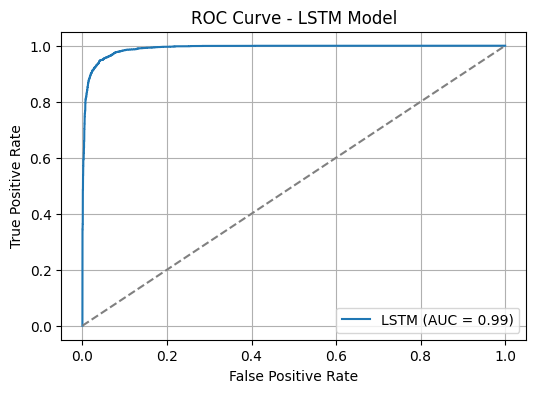

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'LSTM (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LSTM Model')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import joblib

# Save the trained Random Forest model
joblib.dump(rf_model, "random_forest_model.pkl")

# Save the fitted TF-IDF vectorizer
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print(" Model and vectorizer saved successfully.")

 Model and vectorizer saved successfully.


In [ ]:
import joblib

# Load the saved model and TF-IDF vectorizer
model = joblib.load("random_forest_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

def clean_input(text):
    import re
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r"[^a-zA-Z\s]", '', text)
    text = re.sub(r"\s+", ' ', text).strip()
    return text

def predict_news():
    print("\n📰 Fake News Detector CLI")
    print("Type 'exit' to quit.")

    while True:
        user_input = input("\nEnter news article text:\n> ")
        if user_input.lower() == 'exit':
            print("👋 Exiting. Stay informed!")
            break

        # Clean and vectorize the input
        cleaned = clean_input(user_input)
        vectorized = vectorizer.transform([cleaned])

        # Predict label
        prediction = model.predict(vectorized)[0]
        proba = model.predict_proba(vectorized)[0][prediction]

        label = "Real News 🟢" if prediction == 1 else "Fake News 🔴"
        print(f"\nPrediction: {label} (Confidence: {proba:.2f})")

# Run the CLI
predict_news()


📰 Fake News Detector CLI
Type 'exit' to quit.

Enter news article text:
> The European Central Bank held interest rates steady on Thursday, maintaining its cautious stance amid slowing inflation across the eurozone. ECB President Christine Lagarde emphasized that while inflation is moving in the right direction, the bank remains vigilant and is not yet ready to declare victory. Economic growth remains subdued, with policymakers closely monitoring wage pressures and energy prices in the coming months.

Prediction: Fake News 🔴 (Confidence: 0.52)

Enter news article text:
> Scientists have discovered a secret alien base on the far side of the moon, according to leaked documents from a top NASA official. The base is allegedly used by extraterrestrials to observe Earth and manipulate global events. This revelation has sparked calls for a full government disclosure on alien activity and secret space programs.

Prediction: Fake News 🔴 (Confidence: 0.77)

Enter news article text:
> exit
👋 Exi